# Hull Tactical - Market Prediction Japanese Tutorial (日本語チュートリアル)

## Hull Tactical - Market Prediction 概要

### コンペティション概要
- **主催者**: Hull Tactical（クオンツ投資戦略を展開する企業）
- **目的**: 金融市場（特に S&P500 指数）の予測可能性を検証するための挑戦
- **期間**:  
  - 開始: 2025年9月15日  
  - 提出締切: 2025年12月15日  
  - コンペ終了: 2026年6月16日（最終評価を含む）
- **賞金総額**: 100,000ドル（1位 50,000ドル）
- **特徴**: 効率的市場仮説 (Efficient Market Hypothesis) に挑む設計で、実運用性を考慮した評価が行われる。

---

### 課題設定・目的
- **対象**: 米国株式インデックス（S&P 500）の超過リターン
- **タスク**: 市場リターンの予測
- **評価指標**: 修正 Sharpe 比 (modified Sharpe ratio)  
  - リスクを抑えつつ安定的にリターンを獲得できるかを重視
- **制約**: ボラティリティ（変動性）を過剰に高めるだけの戦略は評価されない
- **意図**: 予測精度だけでなく、投資戦略としての持続性・実効性が求められる

---

### モチベーションとチャレンジ点
1. **低シグナル対雑音**  
   市場データはノイズが多く、有意な予測シグナルを見つけることが難しい。  

2. **リスクとリターンのトレードオフ**  
   高リターンを追うだけでは不十分で、ボラティリティ制御が不可欠。  

3. **過剰適合のリスク**  
   特徴量やモデルを複雑にすると、学習データに合っても将来データで性能が落ちる。  

4. **モデルの解釈性・頑健性**  
   実運用を意識すると、極端な出力や不安定な戦略は不利になる。  

5. **評価フェーズの特異性**  
   単なる予測精度だけでなく、**実際の市場リターンとの比較**が評価に組み込まれる。


### 準備

In [1]:
# ライブラリーインポート
#　ライブラリー(いつもの)
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from IPython.display import display

#　ライブラリー(追加)
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

# ディスプレイオプション
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Set professional plotting style
plt.style.use('ggplot')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['font.family'] = 'Arial'
custom_palette = ["#3498db", "#e74c3c", "#2ecc71", "#f39c12", "#9b59b6"]
sns.set_palette(custom_palette)

In [2]:
# データ読み込み
BASE_DIR = "./data"
# BASE_DIR = "/kaggle/input/Hull Tactical - Market Prediction"
train_df = pl.read_csv(BASE_DIR + "/train.csv")
test_df = pl.read_csv(BASE_DIR + "/test.csv")

datasets = {
    "train data" : train_df,
    "test data"  : test_df
}

## データ初期調査

## データの概要 (Data Overview)

### 提供データの構成 

主なファイルは以下のとおりです：

- **train.csv** : 学習用データセット（過去の市場データとターゲットラベル）
- **test.csv** : 評価用データセット（将来期間の市場データ、ターゲットは非公開）

---

### カラム詳細(train.csv)
- *date_id* : 1 取引日の識別子。
- *M\** : 市場の動向/技術的特徴。
- *E\** : マクロ経済の特徴。
- *I\** : 金利機能。
- *P\** : 価格/評価機能。
- *V\** : ボラティリティ機能。
- *S\** : 感情機能。
- *MOM\** : モメンタム機能。
- *D\** : ダミー/バイナリ機能。
- *forward_returns* : S&P 500を購入し、翌日に売却した場合のリターン。列車セットのみ。
- *risk_free_rate* : フェデラルファンド金利。トレーニングセットのみ。
- *market_forward_excess_returns* : 期待値に対するフォワードリターン。5年間のローリング平均フォワードリターンを差し引き、その結果を基準値4の中央絶対偏差（MAD）を用いてウィンザライズすることで算出。トレーニングセットのみ。

### カラム詳細(test.csv)
- *date_id, [feature_name]* : 特徴列は と同じですtrain.csv。
- *is_scored* : この行が評価指標の計算に含まれるかどうか。モデルのトレーニングフェーズでは、最初の180行のみ対象となります。テストセットのみ。
- *lagged_forward_returns* : S&P 500 を購入し、1 日後に売却することで得られるリターン (1 日の遅延あり)。
- *lagged_risk_free_rate* : 1 日遅れのフェデラルファンド金利。
- *lagged_market_forward_excess_returns* : 期待値に対するフォワードリターン。5年間の平均フォワードリターンを差し引き、基準値4の中央絶対偏差（MAD）を用いて1日遅れでウィンザー化して算出。

In [3]:
print("<Shape>")
for name, df in datasets.items():
    print(f"{name}: {df.shape}")

<Shape>
train data: (8990, 98)
test data: (10, 99)


In [4]:
print("<Nan>")
for name, df in datasets.items():
    print(f"{name}:")
    display(df.null_count())

<Nan>
train data:


date_id,D1,D2,D3,D4,D5,D6,D7,D8,D9,E1,E10,E11,E12,E13,E14,E15,E16,E17,E18,E19,E2,E20,E3,E4,E5,E6,E7,E8,E9,I1,I2,I3,I4,I5,I6,I7,…,P13,P2,P3,P4,P5,P6,P7,P8,P9,S1,S10,S11,S12,S2,S3,S4,S5,S6,S7,S8,S9,V1,V10,V11,V12,V13,V2,V3,V4,V5,V6,V7,V8,V9,forward_returns,risk_free_rate,market_forward_excess_returns
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,…,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,1784,1006,1006,1006,1006,1006,1006,1006,1006,1006,1006,1006,1616,1006,1006,1006,1006,6969,1006,1006,1006,1006,1006,1006,1006,1006,1006,…,1006,1006,1006,1006,1574,1638,1616,1006,1006,1006,1006,1006,3537,1006,5733,1006,1511,1006,1006,3009,1006,1006,6049,1006,1006,1511,1006,1006,1006,1512,1006,1511,1006,4539,0,0,0


test data:


date_id,D1,D2,D3,D4,D5,D6,D7,D8,D9,E1,E10,E11,E12,E13,E14,E15,E16,E17,E18,E19,E2,E20,E3,E4,E5,E6,E7,E8,E9,I1,I2,I3,I4,I5,I6,I7,…,P2,P3,P4,P5,P6,P7,P8,P9,S1,S10,S11,S12,S2,S3,S4,S5,S6,S7,S8,S9,V1,V10,V11,V12,V13,V2,V3,V4,V5,V6,V7,V8,V9,is_scored,lagged_forward_returns,lagged_risk_free_rate,lagged_market_forward_excess_returns
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,…,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [5]:
print("Raw Data")
for name, df in datasets.items():
    print(f"<{name}>")
    display(df.sample(5))

Raw Data
<train data>


date_id,D1,D2,D3,D4,D5,D6,D7,D8,D9,E1,E10,E11,E12,E13,E14,E15,E16,E17,E18,E19,E2,E20,E3,E4,E5,E6,E7,E8,E9,I1,I2,I3,I4,I5,I6,I7,…,P13,P2,P3,P4,P5,P6,P7,P8,P9,S1,S10,S11,S12,S2,S3,S4,S5,S6,S7,S8,S9,V1,V10,V11,V12,V13,V2,V3,V4,V5,V6,V7,V8,V9,forward_returns,risk_free_rate,market_forward_excess_returns
i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,…,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,f64,f64,f64
7882,0,0,0,1,0,0,0,0,0,"""1.70928612593902""","""0.252645502645503""","""0.019510582010582""","""0.0876322751322751""","""0.00363756613756614""","""0.0162037037037037""","""0.396494708994709""","""1.49104616992418""","""2.34856529352932""","""2.11678147034235""","""-0.51151315701375""","""3.3708151538512""","""-0.663988492205476""","""3.57351927526265""","""0.000992063492063492""","""0.00793650793650794""","""0.120701058201058""","""0.583213063689939""","""0.145607186275177""","""0.533399470899471""","""0.352513227513228""","""-1.33706308448616""","""0.559854497354497""","""0.229497354497355""","""-1.08522520198569""","""0.845899470899471""","""0.398148148148148""",…,"""0.150793650793651""","""-3.12300297954163""","""0.689153439153439""","""0.0753968253968254""","""1.28939131800712""","""-0.421634960697291""","""1.44792684071226""","""1.75929592493999""","""0.272156084656085""","""2.6413640247518""","""0.645502645502645""","""0.645502645502645""","""1.01386425971127""","""1.35448495319646""","""1.32930090820985""","""0.571428571428571""","""-0.325398635552535""","""0.911375661375661""","""0.6875""","""1.57449532506531""","""0.552248677248677""","""0.461640211640212""","""0.419719636433664""","""0.194444444444444""","""0.0502645502645503""","""-0.0772869606681071""","""0.416666666666667""","""0.279761904761905""","""0.482804232804233""","""0.864887614752826""","""0.294312169312169""","""-0.14460820179885""","""0.475529100529101""","""0.159262783178668""",0.003342,3.9683e-7,0.003035
6791,0,0,0,1,0,0,0,0,0,"""0.745641409733793""","""0.349537037037037""","""0.0042989417989418""","""0.0042989417989418""","""0.0042989417989418""","""0.0042989417989418""","""0.127645502645503""","""-0.542052775496035""","""-0.0308161612819744""","""0.0461316945428833""","""-0.567300512675951""","""1.48325936299742""","""-0.306977263066976""","""0.245345393027003""","""0.00165343915343915""","""0.984457671957672""","""0.0112433862433862""",null,"""-1.33643179650733""","""0.0529100529100529""","""0.936838624338624""","""-0.344161242721611""","""0.591269841269841""","""0.755291005291005""","""4.10909296769729""","""0.0826719576719577""","""0.944444444444444""",…,"""0.751322751322751""","""-0.100291617735053""","""0.906084656084656""","""0.417328042328042""","""2.38909467331627""","""-0.480385912146397""","""-0.880182285907142""","""1.97393909324057""","""0.19047619047619""","""0.0701858435719757""","""0.606481481481482""","""0.795634920634921""","""0.187213227349138""","""1.8022866529721""","""1.42481322065734""","""0.789021164021164""","""-0.574475421053801""","""0.574404761904762""","""0.347222222222222""","""0.965673405735318""","""0.271825396825397""","""0.633597883597884""","""-0.614381186846449""","""0.990740740740741""","""0.178240740740741""","""-0.584759017463011""","""0.51521164021164""","""0.106481481481481""","""0.751322751322751""","""-0.84934074043742""","""0.0317460317460317""","""-0.819338879782745""","""0.81712962962963""","""-0.670114003877223""",0.006674,0.00002,0.006347
2242,0,0,1,1,0,0,0,0,0,"""1.40774147077689""","""0.743386243386243""","""0.00165343915343915""","""0.00165343915343915""","""0.017526455026455""","""0.00165343915343915""","""0.00231481481481481""","""-1.0939491050784""","""-0.981857899054435""","""-1.58541061011765""","""0.719491445393364""","""1.82214524373484""","""1.04108555426695""","""1.73398324915146""","""0.0062830687830687

<test data>


date_id,D1,D2,D3,D4,D5,D6,D7,D8,D9,E1,E10,E11,E12,E13,E14,E15,E16,E17,E18,E19,E2,E20,E3,E4,E5,E6,E7,E8,E9,I1,I2,I3,I4,I5,I6,I7,…,P2,P3,P4,P5,P6,P7,P8,P9,S1,S10,S11,S12,S2,S3,S4,S5,S6,S7,S8,S9,V1,V10,V11,V12,V13,V2,V3,V4,V5,V6,V7,V8,V9,is_scored,lagged_forward_returns,lagged_risk_free_rate,lagged_market_forward_excess_returns
i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool,f64,f64,f64
8982,0,0,0,0,1,0,0,0,1,1.57272,0.185516,0.000661,0.000661,0.000661,0.000661,0.955688,-0.083356,-0.573546,0.225822,-0.393903,1.123361,1.551723,1.562722,0.032407,0.332672,0.035714,0.033581,-0.312364,0.91369,0.291997,1.040514,0.081349,0.477513,0.655741,0.724206,0.22619,…,-1.34762,0.210979,0.635251,-1.138198,-0.494248,-1.042718,1.754171,0.032407,0.257609,0.082011,0.152116,-0.201611,0.346373,0.054032,0.137566,0.294305,0.194444,0.409392,0.596528,0.778439,0.634921,-0.483236,0.669974,0.603836,-0.17042,0.848545,0.647487,0.832672,1.088992,0.665344,-0.459367,0.199405,-0.510979,true,-0.00741,0.00016,-0.007882
8981,0,0,0,0,1,0,0,1,0,1.575182,0.185847,0.000992,0.000992,0.000992,0.000992,0.955357,-0.583074,-0.703759,0.297608,-0.504499,1.193468,1.554184,1.640054,0.032738,0.333003,0.036045,0.073582,-0.312345,0.91336,0.305886,0.989571,0.082672,0.477844,0.661527,0.719577,0.255952,…,-1.37652,0.953042,0.386905,0.523549,-0.421365,-0.234829,1.770175,0.03373,0.304496,0.638228,0.636905,1.849101,0.28169,-0.041995,0.448413,0.094321,0.215608,0.409392,0.597864,0.872354,0.691138,-0.583443,0.62996,0.598545,-0.394268,0.863757,0.699074,0.831349,1.120336,0.556217,-0.686192,0.141865,-0.660326,true,-0.005964,0.000162,-0.006437
8980,0,0,0,0,1,0,0,1,0,1.577651,0.186177,0.001323,0.001323,0.001323,0.001323,0.955026,-0.583419,-0.704264,0.298365,-0.691361,1.259065,1.556516,1.71258,0.033069,0.333333,0.036376,-0.046483,-0.312326,0.913029,0.306217,1.025756,0.081349,0.478175,0.675627,0.699735,0.256283,…,-1.427834,0.352513,0.926257,0.431383,-0.476976,0.500245,1.784173,0.029762,0.294719,0.51455,0.446429,0.466551,0.085717,-0.230132,0.272487,-0.106894,0.199735,0.409392,0.532717,0.744048,0.440476,-0.654839,0.699735,0.699074,-0.5024,0.882937,0.892196,0.828042,0.999172,0.759921,-0.803127,0.170966,-0.751909,true,0.003541,0.000161,0.003068
8985,0,0,0,0,0,0,0,0,0,1.565379,0.184524,0.01918,0.01918,0.005952,0.005952,0.911376,-0.083496,-0.572447,0.223638,-0.122314,1.20925,1.540116,1.655174,0.031415,0.33168,0.034722,0.038269,-0.301876,0.914683,0.27414,0.984115,0.080688,0.476521,0.597442,0.718254,0.238757,…,-1.354498,0.046296,0.51455,0.276769,-0.261326,0.811754,1.784929,0.039683,0.249933,0.273148,0.134921,0.634465,-0.446682,-0.052686,0.083995,0.055282,0.209656,0.409392,0.574661,0.748677,0.498677,-0.616395,0.561839,0.53373,-0.432282,0.785053,0.469577,0.837963,1.226772,0.822751,-0.707361,0.142857,-0.649616,true,-0.002896,0.000159,-0.003365
8983,0,0,0,0,1,0,0,0,1,1.570266,0.185185,0.019841,0.019841,0.006614,0.006614,0.956019,-0.083403,-0.57318,0.225094,-0.541646,1.167982,1.549272,1.611215,0.032077,0.332341,0.035384,0.033998,-0.312383,0.914021,0.267196,1.091376,0.085979,0.477183,0.648582,0.728175,0.230159,…,-1.399411,0.724868,0.21627,-0.230557,-0.318347,0.396917,1.769678,0.03373,0.20235,0.324074,0.212963,0.052878,-0.049023,0.120828,0.219577,0.137942,0.167328,0.409392,0.579726,0.449735,0.665344,-0.546298,0.590608,0.558862,-0.275099,0.826058,0.445767,0.835979,1.040988,0.594577,-0.561643,0.161706,-0.575997,true,0.00542,0.00016,0.004949


In [6]:
#何故かtrainデータにstr型のデータが混ざっているのでintになおしておく

train_df = train_df.with_columns([
    pl.col(col).cast(pl.Float64, strict=False).alias(col)
    for col in train_df.columns
])

display(train_df.sample(10))

date_id,D1,D2,D3,D4,D5,D6,D7,D8,D9,E1,E10,E11,E12,E13,E14,E15,E16,E17,E18,E19,E2,E20,E3,E4,E5,E6,E7,E8,E9,I1,I2,I3,I4,I5,I6,I7,…,P13,P2,P3,P4,P5,P6,P7,P8,P9,S1,S10,S11,S12,S2,S3,S4,S5,S6,S7,S8,S9,V1,V10,V11,V12,V13,V2,V3,V4,V5,V6,V7,V8,V9,forward_returns,risk_free_rate,market_forward_excess_returns
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
8404.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.514798,0.523148,0.003638,0.019511,0.016204,0.003638,0.700066,-1.266163,-1.616546,-0.706693,-0.185452,-0.679905,1.304665,-0.635422,0.000992,0.998347,0.018519,-0.009351,-0.267295,0.328373,0.733135,1.684202,0.373347,0.385582,2.683423,0.493386,0.585317,…,0.759259,-0.339728,0.950397,0.411376,-0.42103,-0.055606,-1.006622,2.21241,0.037037,-0.0379,0.718254,0.814815,1.585317,0.047595,-0.354851,0.853836,-0.359103,0.648479,0.15377,-0.860728,0.423942,0.066138,0.018551,0.079034,0.1875,-0.274373,0.065476,0.017857,0.131614,0.648398,0.569444,-0.373984,0.053902,-0.186745,-0.00131,0.000199,-0.001822
7957.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.676862,0.290344,0.032077,0.022817,0.006283,0.006283,0.435516,0.985246,1.042671,1.787668,-0.470964,2.785259,2.159481,3.031497,0.033069,0.004299,0.04795,0.353288,-0.097895,0.594907,0.925595,-1.851451,0.443122,0.272487,-1.053492,0.625,0.554894,…,0.659061,-2.679422,0.512235,0.916005,0.723288,-0.331256,0.310835,2.120945,0.164021,3.387095,0.952381,0.744709,0.986285,-0.496105,0.734938,0.787698,-0.015655,0.24504,0.449735,0.99466,0.445437,0.303571,0.633654,0.19709,0.063492,0.432496,0.522487,0.207011,0.530423,2.302801,0.517196,0.178205,0.311177,0.436138,0.008135,0.000002,0.007826
5526.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,1.646489,0.322751,0.075728,0.256944,0.006283,0.006283,0.705357,-0.218251,-0.026397,-1.387421,-0.127043,-0.536448,1.108409,-0.518378,0.030423,0.433532,0.012897,null,-0.112639,0.525463,0.579365,-1.534593,0.691138,0.651124,-0.889384,0.299603,0.728175,…,0.602844,-0.050227,0.597884,0.083003,-0.088293,-0.319807,-0.679797,1.137929,0.839286,-0.771077,0.318122,0.40873,0.317278,-0.303823,null,0.330026,-0.724758,0.988757,0.871032,-0.803987,0.657407,0.140212,null,0.154101,0.820767,0.46878,0.185185,0.243386,0.103836,-0.551799,0.208995,0.35209,0.820767,0.587443,-0.00088,5.9524e-7,-0.001187
3129.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.432163,0.430556,0.774802,0.848214,0.013558,0.000992,0.19246,1.06325,0.336081,0.881952,-0.511514,-1.020227,-1.860912,-1.47026,0.005291,0.541667,0.015873,null,1.617938,0.00496,0.795966,0.511743,0.98545,0.398479,-2.450754,0.831349,0.906085,…,0.930886,0.04232,0.479167,0.079365,-0.354847,-0.491338,-0.174263,0.965058,0.08664,-0.647411,0.73082,0.73082,null,-0.182198,null,0.73082,-0.003432,0.852844,0.169643,-1.852889,0.73082,0.000661,null,0.000661,0.000661,-0.527732,0.051587,0.037698,0.078704,-0.195487,0.000661,-0.579768,0.000661,null,-0.002796,0.000068,-0.003172
3971.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.713133,0.368056,0.108796,0.067791,0.000992,0.000992,0.805225,0.285579,0.09431,0.08499,-0.714703,-0.575586,1.523927,-0.53029,0.005291,0.11541,0.008267,null,-0.03232,0.019511,0.781746,-1.375475,0.23082,0.766204,0.385506,0.109127,0.842593,…,0.103175,1.015931,0.385582,0.073413,0.259882,0.159722,1.652255,2.128183,0.832011,0.393176,0.347884,0.406746,-0.78836,-0.786259,null,0.39418,-0.44769,0.353175,0.17791,0.287178,0.728836,0.121032,null,0.000661,0.000661,-1.02437,0.605159,0.560847,0.633598,1.237576,0.121032,-1.402155,0.000661,null,0.003098,0.000137,0.002651
2864.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.930223,0.155754,0.916667,0.98082,0.003968,0.003968,0.159722,-2.306389,-2.265262,0.309637,0.428552,-0.177476,-0.268267,-0.16477,0.001984,0.880291,0.058862,null,2.53378,0.064484,0.934854,0.297169,0.986442,0.85086,-2.724091,0.859788,0.87037,…,0.874339,-0.775351,0.246

## 欠損値分析
上で行った初期調査を眺めるとまず気になるのは欠損値の多さです。合計で137,675の欠損値が存在し、これは全セルの15．63%に相当します。ここまで大きな欠損となるとモデルの精度に影響を与えることは一目瞭然です。しかし、欠損値もうまく利用してモデルの精度を改善することができる場合があります。欠損値をもっとよく調べて見ましょう。

Total missing values: 137,675 (15.63% of all cells)

📊 Top 20 columns with missing values:


,Missing_Count,Missing_Percentage
E7,6969.0,77.519466
V10,6049.0,67.285873
S3,5733.0,63.770857
M1,5547.0,61.701891
M14,5540.0,61.624027
M13,5540.0,61.624027
M6,5043.0,56.095662
V9,4539.0,50.489433
S12,3537.0,39.343715
M5,3283.0,36.518354


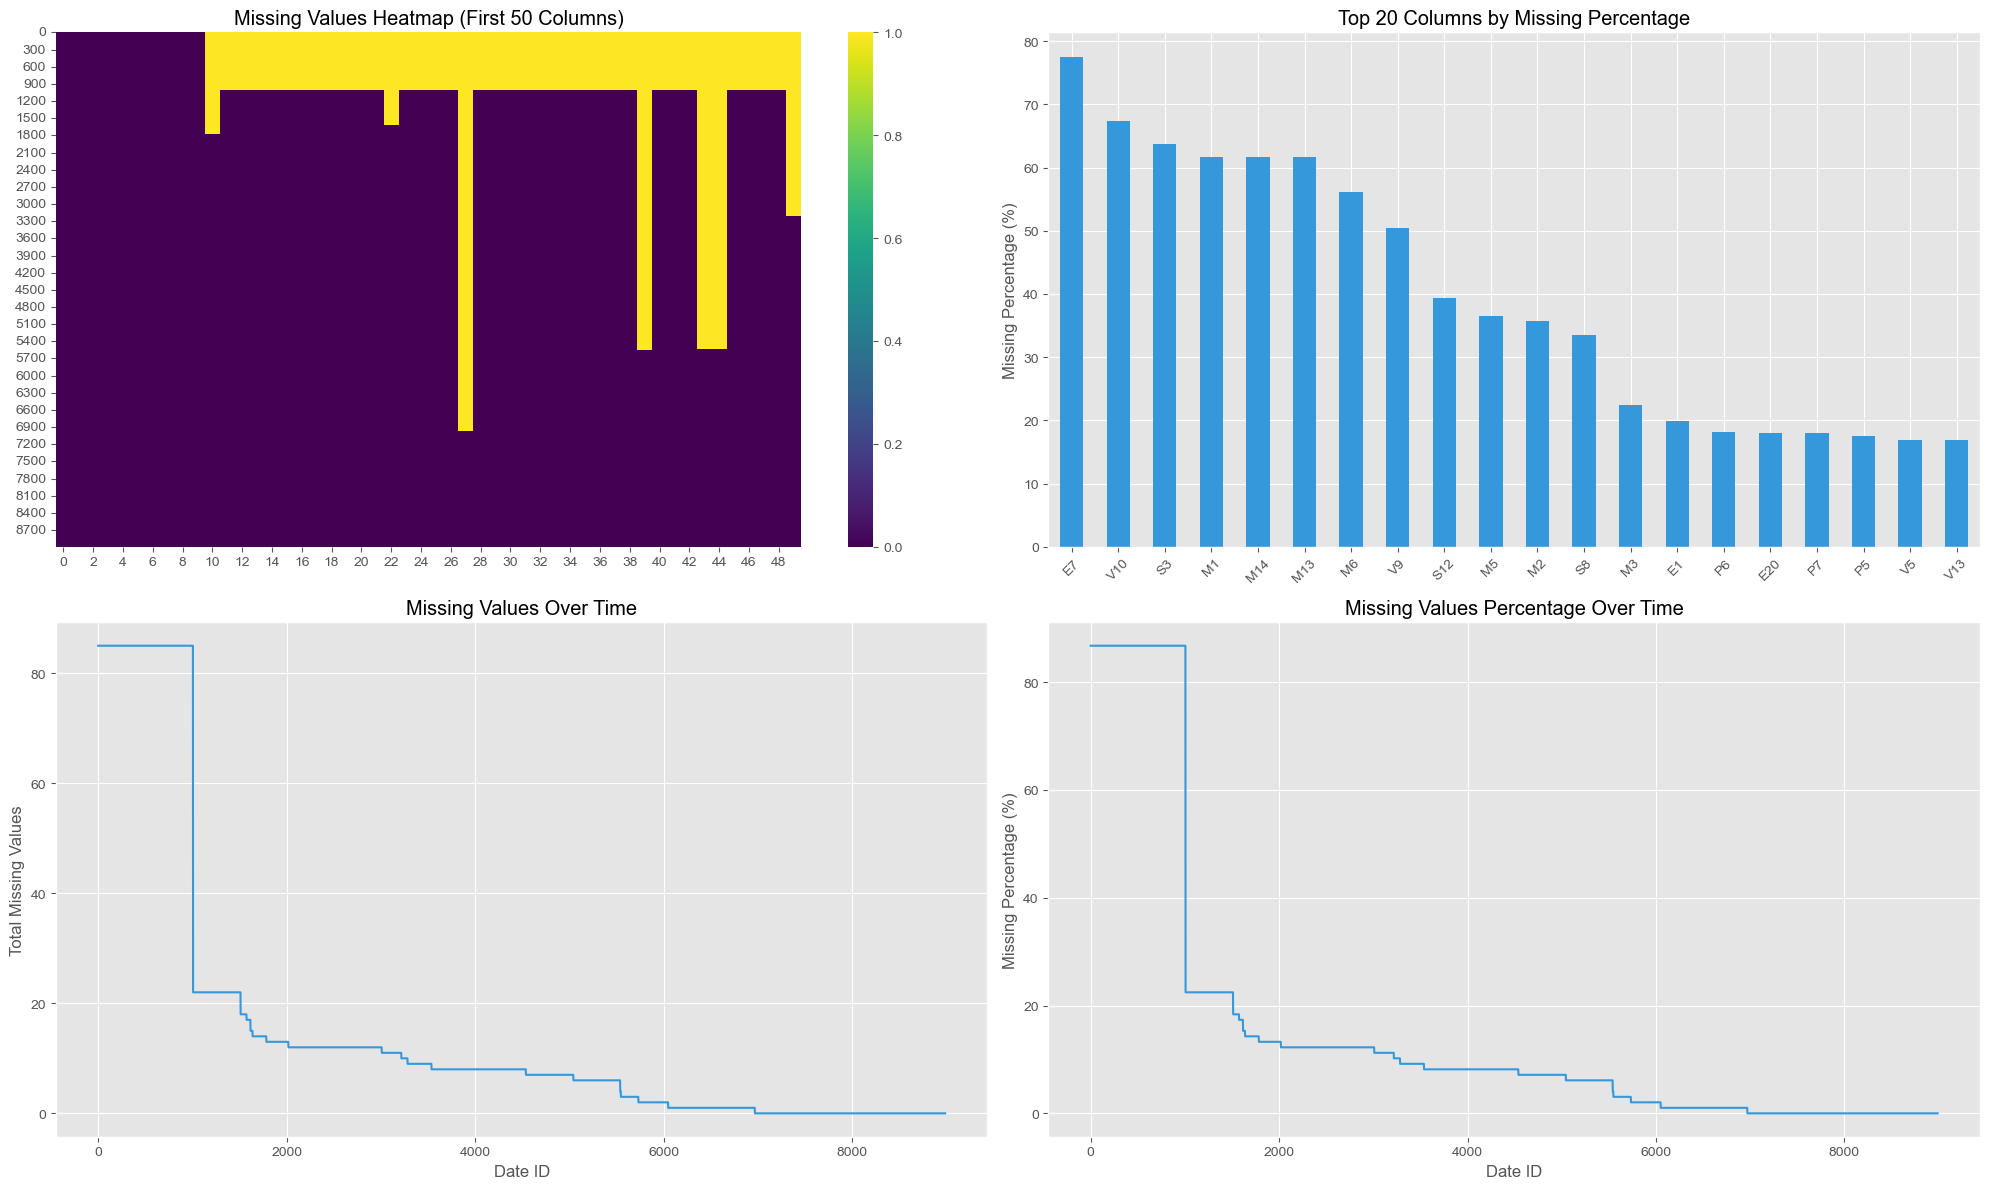

In [7]:

def analyze_missing_values_pl(df: pl.DataFrame):
    """Comprehensive missing values analysis for a Polars DataFrame (version-safe as possible)"""

    print("=" * 50)
    
    #-------------------------------------
    # 全体集計
    #-------------------------------------
    rows, cols = df.height, df.width
    total_cells = rows * cols

    # 各列の欠損数
    null_count_row = df.null_count().row(0)   # タプル (col1_nulls, col2_nulls, ...)
    total_missing = sum(null_count_row)
    missing_percentage = (total_missing / total_cells) * 100 if total_cells > 0 else 0.0
    
    print(f"Total missing values: {total_missing:,} ({missing_percentage:.2f}% of all cells)")
    
    #-------------------------------------
    # 列ごとの欠損数（pandas Series で扱う）
    #-------------------------------------
    missing_data = pd.Series(
        dict(zip(df.columns, null_count_row)),
        dtype="float64"
    )
    missing_data = missing_data[missing_data > 0].sort_values(ascending=False)
    
    if len(missing_data) > 0:
        missing_percent = (missing_data / rows) * 100
        missing_df = pd.DataFrame({
            "Missing_Count": missing_data,
            "Missing_Percentage": missing_percent
        })

        print("\n📊 Top 20 columns with missing values:")
        display(missing_df.head(20))
        
        #-------------------------------------
        # 可視化
        #-------------------------------------
        fig, axes = plt.subplots(2, 2, figsize=(20, 12))
        
        #-------------------------------------
        # ① ヒートマップ（最初の50列）
        #-------------------------------------
        first50 = df.select(df.columns[:50])

        # 各列 is_null() を取って DataFrame にし、そのまま NumPy 配列へ
        missing_bool_df = first50.select(
            [pl.col(c).is_null().alias(c) for c in first50.columns]
        )
        missing_np = missing_bool_df.to_numpy()  # shape = (rows, min(50, cols))

        sns.heatmap(missing_np, cbar=True, ax=axes[0,0], cmap="viridis")
        axes[0,0].set_title("Missing Values Heatmap (First 50 Columns)")
        
        #-------------------------------------
        # ② 欠損率上位20列の棒グラフ
        #-------------------------------------
        top_missing = missing_df.head(20)
        top_missing["Missing_Percentage"].plot(kind="bar", ax=axes[0,1])
        axes[0,1].set_title("Top 20 Columns by Missing Percentage")
        axes[0,1].set_ylabel("Missing Percentage (%)")
        plt.setp(axes[0,1].xaxis.get_majorticklabels(), rotation=45)
        
        #-------------------------------------
        # ③ 時系列推移（date_id 列がある場合）
        #-------------------------------------
        if "date_id" in df.columns:
    
            row_missing_df = df.with_columns(
                pl.fold(
                    acc=pl.lit(0),
                    exprs=[pl.col(c).is_null().cast(pl.Int64) for c in df.columns],
                    function=lambda acc, x: acc + x,
                ).alias("row_missing")
            )

            missing_by_date = (
                row_missing_df
                .group_by("date_id")
                .agg(pl.col("row_missing").sum().alias("total_missing"))
                .sort("date_id")
            )
            
            # Polars → Python リスト / NumPy にしてプロット
            date_vals = missing_by_date["date_id"].to_list()
            missing_vals = missing_by_date["total_missing"].to_numpy()
            
            # 日付ごとの欠損数
            axes[1,0].plot(date_vals, missing_vals)
            axes[1,0].set_title("Missing Values Over Time")
            axes[1,0].set_xlabel("Date ID")
            axes[1,0].set_ylabel("Total Missing Values")
            
            # 日付ごとの欠損率（列数で割る）
            missing_pct_vals = (missing_vals / cols) * 100
            axes[1,1].plot(date_vals, missing_pct_vals)
            axes[1,1].set_title("Missing Values Percentage Over Time")
            axes[1,1].set_xlabel("Date ID")
            axes[1,1].set_ylabel("Missing Percentage (%)")
        
        plt.tight_layout()
        plt.show()
    
    return missing_data  # pandas.Series（列ごとの欠損数）

# 呼び出し
# missing_analysis = analyze_missing_values_pl(train_df)


missing_analysis = analyze_missing_values_pl(train_df)

*欠損データのある上位の特徴*<br>
次の列は欠損の度合いが最も高いものを示しています。
- E7→ 77.5%が欠落
- V10→ 67.3%が行方不明
- S3→ 63.8%が行方不明
- M1、、→ それぞれ約61.6％が M13欠損M14
これらの特徴は、特徴削除（冗長であると判断された場合）または特別な補完（ドメイン知識により重要な情報が含まれていると判断された場合）の候補となります。

*中程度の影響を受けた特徴量*<br>
(欠損値が30～50%）：、、など
の列がこの範囲に該当します。これらの列は、慎重に補完すれば依然としてシグナルとなる可能性がありますが、適切に処理しないとノイズとなる可能性もあります。
- M6
- V9
- S12

*軽度に影響のある特徴量*<br>
（欠損値 < 25%）：、、、、、、、など
の列の欠損値は16～22%です。堅牢な補完戦略（中央値補完、前方補完、予測補完）を適用する限り、これらの列は通常、保持する価値があります。
- E1
- P6
- E20
- P7
- P5
- V5
- S5

## 統計分析

In [8]:
print("<Describe>")
for name, df in datasets.items():
    print(f"{name}")
    display(df.describe())

<Describe>
train data


statistic,date_id,D1,D2,D3,D4,D5,D6,D7,D8,D9,E1,E10,E11,E12,E13,E14,E15,E16,E17,E18,E19,E2,E20,E3,E4,E5,E6,E7,E8,E9,I1,I2,I3,I4,I5,I6,…,P13,P2,P3,P4,P5,P6,P7,P8,P9,S1,S10,S11,S12,S2,S3,S4,S5,S6,S7,S8,S9,V1,V10,V11,V12,V13,V2,V3,V4,V5,V6,V7,V8,V9,forward_returns,risk_free_rate,market_forward_excess_returns
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,…,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,f64,f64,f64
"""count""",8990.0,8990.0,8990.0,8990.0,8990.0,8990.0,8990.0,8990.0,8990.0,8990.0,"""7206""","""7984""","""7984""","""7984""","""7984""","""7984""","""7984""","""7984""","""7984""","""7984""","""7984""","""7984""","""7374""","""7984""","""7984""","""7984""","""7984""","""2021""","""7984""","""7984""","""7984""","""7984""","""7984""","""7984""","""7984""","""7984""",…,"""7984""","""7984""","""7984""","""7984""","""7416""","""7352""","""7374""","""7984""","""7984""","""7984""","""7984""","""7984""","""5453""","""7984""","""3257""","""7984""","""7479""","""7984""","""7984""","""5981""","""7984""","""7984""","""2941""","""7984""","""7984""","""7479""","""7984""","""7984""","""7984""","""7478""","""7984""","""7479""","""7984""","""4451""",8990.0,8990.0,8990.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""1784""","""1006""","""1006""","""1006""","""1006""","""1006""","""1006""","""1006""","""1006""","""1006""","""1006""","""1006""","""1616""","""1006""","""1006""","""1006""","""1006""","""6969""","""1006""","""1006""","""1006""","""1006""","""1006""","""1006""","""1006""","""1006""",…,"""1006""","""1006""","""1006""","""1006""","""1574""","""1638""","""1616""","""1006""","""1006""","""1006""","""1006""","""1006""","""3537""","""1006""","""5733""","""1006""","""1511""","""1006""","""1006""","""3009""","""1006""","""1006""","""6049""","""1006""","""1006""","""1511""","""1006""","""1006""","""1006""","""1512""","""1006""","""1511""","""1006""","""4539""",0.0,0.0,0.0
"""mean""",4494.5,0.031591,0.031591,0.047831,0.575195,0.190656,-0.238042,0.045717,0.142825,0.143159,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,0.000469,0.000107,0.000051
"""std""",2595.333794,0.174917,0.174917,0.21342,0.494341,0.39284,0.425909,0.208883,0.349914,0.350254,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,0.010551,0.000088,0.010568
"""min""",0.0,0.0,0.0,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,"""0.325149307781904""","""0.000661375661375661""","""0.000661375661375661""","""0.000661375661375661""","""0.000661375661375661""","""0.000661375661375661""","""0.000661375661375661""","""-0.000106995292857562""","""-0.000216543653035166""","""-0.0370537162477823""","""-0.00103514761966728""","""-0.000286476485653406""","""-0.0148789892924795""","""-0.000109469415770866""","""0.000661375661375661""","""0.000661375661375661""","""0.000661375661375661""","""-0.00191866426052122""","""-0.000332320536729127""","""0.000661375661375661""","""0.00264550264550265""","""-0.000158919870282691""","""0.000661375661375661""","""0.000661375661375661""","""-0.00107541867648806""","""0.000661375661375661""",…,"""0.00231481481481481""","""-0.000380178000909207""","""0.0439814814814815""","""0.0661375661375661""","""-0.0000605148090623544""","""-0.000612006826255119""","""-0.0000466649000800819""","""-0.00013672794415026""","""0.000661375661375661""","""-0.000096336366423328""","""0.00066137

test data


statistic,date_id,D1,D2,D3,D4,D5,D6,D7,D8,D9,E1,E10,E11,E12,E13,E14,E15,E16,E17,E18,E19,E2,E20,E3,E4,E5,E6,E7,E8,E9,I1,I2,I3,I4,I5,I6,…,P2,P3,P4,P5,P6,P7,P8,P9,S1,S10,S11,S12,S2,S3,S4,S5,S6,S7,S8,S9,V1,V10,V11,V12,V13,V2,V3,V4,V5,V6,V7,V8,V9,is_scored,lagged_forward_returns,lagged_risk_free_rate,lagged_market_forward_excess_returns
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,…,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",8984.5,0.0,0.0,0.1,0.0,0.4,0.0,0.1,0.2,0.3,1.566627,0.184689,0.013492,0.013492,0.004233,0.004233,0.933862,-0.183636,-0.598795,0.238234,-0.584514,1.225412,1.542907,1.673009,0.031581,0.331845,0.034888,0.031407,-0.302658,0.914517,0.282804,0.957083,0.081614,0.477877,0.630171,0.718783,…,-1.402797,0.483796,0.417361,0.188995,-0.32594,0.444488,1.782248,0.038161,0.303177,0.450661,0.353704,0.653249,-0.070573,-0.205986,0.296627,0.045692,0.218122,0.409392,0.587802,0.661772,0.543981,-0.604714,0.505192,0.520569,-0.38614,0.787434,0.573743,0.819907,1.010369,0.747487,-0.679972,0.145238,-0.649404,1.0,0.001702,0.000158,0.001232
"""std""",3.02765,0.0,0.0,0.316228,0.0,0.516398,0.0,0.316228,0.421637,0.483046,0.007388,0.001001,0.008647,0.008647,0.002316,0.002316,0.023011,0.210614,0.055457,0.031531,0.205915,0.054477,0.009505,0.058473,0.001001,0.001001,0.001001,0.029955,0.013344,0.001001,0.017817,0.093216,0.005751,0.00086,0.028975,0.009461,…,0.037741,0.300459,0.238504,0.60086,0.106784,0.831943,0.013457,0.005998,0.07338,0.296879,0.266854,0.669503,0.259807,0.273719,0.199868,0.12097,0.059294,0.0,0.028391,0.194999,0.116091,0.056397,0.177948,0.102121,0.095649,0.072821,0.223494,0.024329,0.131349,0.111075,0.099564,0.038423,0.065991,null,0.005482,0.000002,0.005483
"""min""",8980.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.55569,0.183201,0.000661,0.000661,0.000661,0.000661,0.911376,-0.583419,-0.704264,0.220814,-0.800465,1.123361,1.529875,1.562722,0.030093,0.330357,0.033399,-0.046483,-0.312383,0.913029,0.260913,0.822594,0.073413,0.476521,0.597442,0.699735,…,-1.469985,0.046296,0.068783,-1.138198,-0.494248,-1.042718,1.754171,0.029762,0.20235,0.011905,0.026455,-0.201611,-0.446682,-0.64248,0.066138,-0.106894,0.130291,0.409392,0.532717,0.37037,0.318783,-0.66805,0.12963,0.37004,-0.5024,0.66336,0.066799,0.78373,0.785877,0.556217,-0.803127,0.079034,-0.751909,1.0,-0.00741,0.000155,-0.007882
"""25%""",8982.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.56052,0.183862,0.001323,0.001323,0.001323,0.001323,0.912037,-0.084538,-0.573546,0.222211,-0.732397,1.193468,1.534742,1.640054,0.030754,0.331019,0.034061,0.033581,-0.312345,0.91369,0.269841,0.858582,0.080688,0.477183,0.604658,0.718254,…,-1.427834,0.232143,0.244378,0.044888,-0.421365,-0.234829,1.770175,0.03373,0.249933,0.273148,0.134921,0.052878,-0.316882,-0.422374,0.137566,-0.02977,0.194444,0.409392,0.574661,0.477513,0.462302,-0.64204,0.394841,0.433532,-0.432282,0.734127,0.469577,0.787698,0.944593,0.665344,-0.723949,0.124669,-0.670946,null,-0.002896,0.000156,-0.003365
"""50%""",8985.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.567818,0.184854,0.018519,0.018519,0.005291,0.005291,0.955026,-0.083542,-0.572447,0.224366,-0.596939,1.24371

## 特徴の分類

In [9]:
import polars as pl

def categorize_features_pl(df: pl.DataFrame):
    """Categorize features based on their prefixes (for Polars DataFrame)"""
    
    print("\n🏷️ FEATURE CATEGORIZATION")
    print("="*50)
    
    feature_categories = {}
    
    # Define feature categories based on prefixes
    categories = {
        'Market_Dynamics': 'M',
        'Macro_Economic': 'E',
        'Interest_Rate': 'I',
        'Price_Valuation': 'P',
        'Volatility': 'V',
        'Sentiment': 'S',
        'Momentum': 'MOM',
        'Dummy_Binary': 'D'
    }
    
    # Categorize features
    for category, prefix in categories.items():
        if prefix == 'MOM':
            feature_categories[category] = [
                col for col in df.columns 
                if col.startswith(prefix)
            ]
        else:
            feature_categories[category] = [
                col for col in df.columns 
                if col.startswith(prefix) and not col.startswith('MOM')
            ]
    
    # Special columns
    special_cols = ['date_id', 'forward_returns', 'risk_free_rate', 'market_forward_excess_returns']
    feature_categories['Special'] = [col for col in special_cols if col in df.columns]
    
    # Display categorization
    total_features = 0
    for category, features in feature_categories.items():
        print(f"📊 {category}: {len(features)} features")
        total_features += len(features)
    
    print(f"\n📈 Total categorized features: {total_features}")
    print(f"📈 Total columns in dataset: {df.width}")
    
    return feature_categories

# 使い方
feature_categories = categorize_features_pl(train_df)



🏷️ FEATURE CATEGORIZATION
📊 Market_Dynamics: 18 features
📊 Macro_Economic: 20 features
📊 Interest_Rate: 9 features
📊 Price_Valuation: 13 features
📊 Volatility: 13 features
📊 Sentiment: 12 features
📊 Momentum: 0 features
📊 Dummy_Binary: 9 features
📊 Special: 4 features

📈 Total categorized features: 98
📈 Total columns in dataset: 98


## 相関分析

In [10]:
print("<Correlation analysis>")
display(train_df.select(pl.col(pl.NUMERIC_DTYPES)).corr())

<Correlation analysis>


C:\Users\Atsuya_Watanabe\AppData\Local\Temp\ipykernel_19360\3305261863.py:2: DeprecationWarning: `NUMERIC_DTYPES` was deprecated in version 1.0.0. Define your own data type groups or use the `polars.selectors` module for selecting columns of a certain data type.
  display(train_df.select(pl.col(pl.NUMERIC_DTYPES)).corr())


date_id,D1,D2,D3,D4,D5,D6,D7,D8,D9,E1,E10,E11,E12,E13,E14,E15,E16,E17,E18,E19,E2,E20,E3,E4,E5,E6,E7,E8,E9,I1,I2,I3,I4,I5,I6,I7,…,P13,P2,P3,P4,P5,P6,P7,P8,P9,S1,S10,S11,S12,S2,S3,S4,S5,S6,S7,S8,S9,V1,V10,V11,V12,V13,V2,V3,V4,V5,V6,V7,V8,V9,forward_returns,risk_free_rate,market_forward_excess_returns
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1.0,-0.000537,-0.000537,0.005556,-0.010921,0.001118,-0.001235,0.005398,0.001531,0.000352,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,…,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.004552,-0.519443,0.008912
-0.000537,1.0,1.0,-0.00472,0.005976,0.014334,0.009862,-0.033443,0.011701,-0.003009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,…,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.03418,0.001097,0.034185
-0.000537,1.0,1.0,-0.00472,0.005976,0.014334,0.009862,-0.033443,0.011701,-0.003009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,…,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.03418,0.001097,0.034185
0.005556,-0.00472,-0.00472,1.0,0.005975,-0.104801,0.108139,-0.049057,-0.088509,-0.090125,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,…,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.005944,-0.008318,0.005988
-0.010921,0.005976,0.005976,0.005975,1.0,0.006941,-0.007441,-0.000436,0.005435,0.006248,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,…,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.016584,-0.00737,0.016629
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,…,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,…,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0.004552,0.03418,0.03418,0.005944,0.016584,0.016642,0.017044,0.010619,0.024739,0.001143,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,…,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,-0.001126,0.999957


🎯 TOP 20 FEATURES CORRELATED WITH FORWARD RETURNS:
market_forward_excess_returns    0.999957
V13                              0.063071
M1                               0.044979
S5                               0.040562
D2                               0.034180
D1                               0.034180
M2                               0.033464
V7                               0.032736
V10                              0.031712
M17                              0.024940
D8                               0.024739
S12                              0.024633
E19                              0.024513
S6                               0.022385
D6                               0.017044
D5                               0.016642
D4                               0.016584
V9                               0.016583
M3                               0.016095
E6                               0.015650
dtype: float64

🎯 BOTTOM 20 FEATURES CORRELATED WITH FORWARD RETURNS:
P11   -0.009475
S8    -0.010532
P3    -

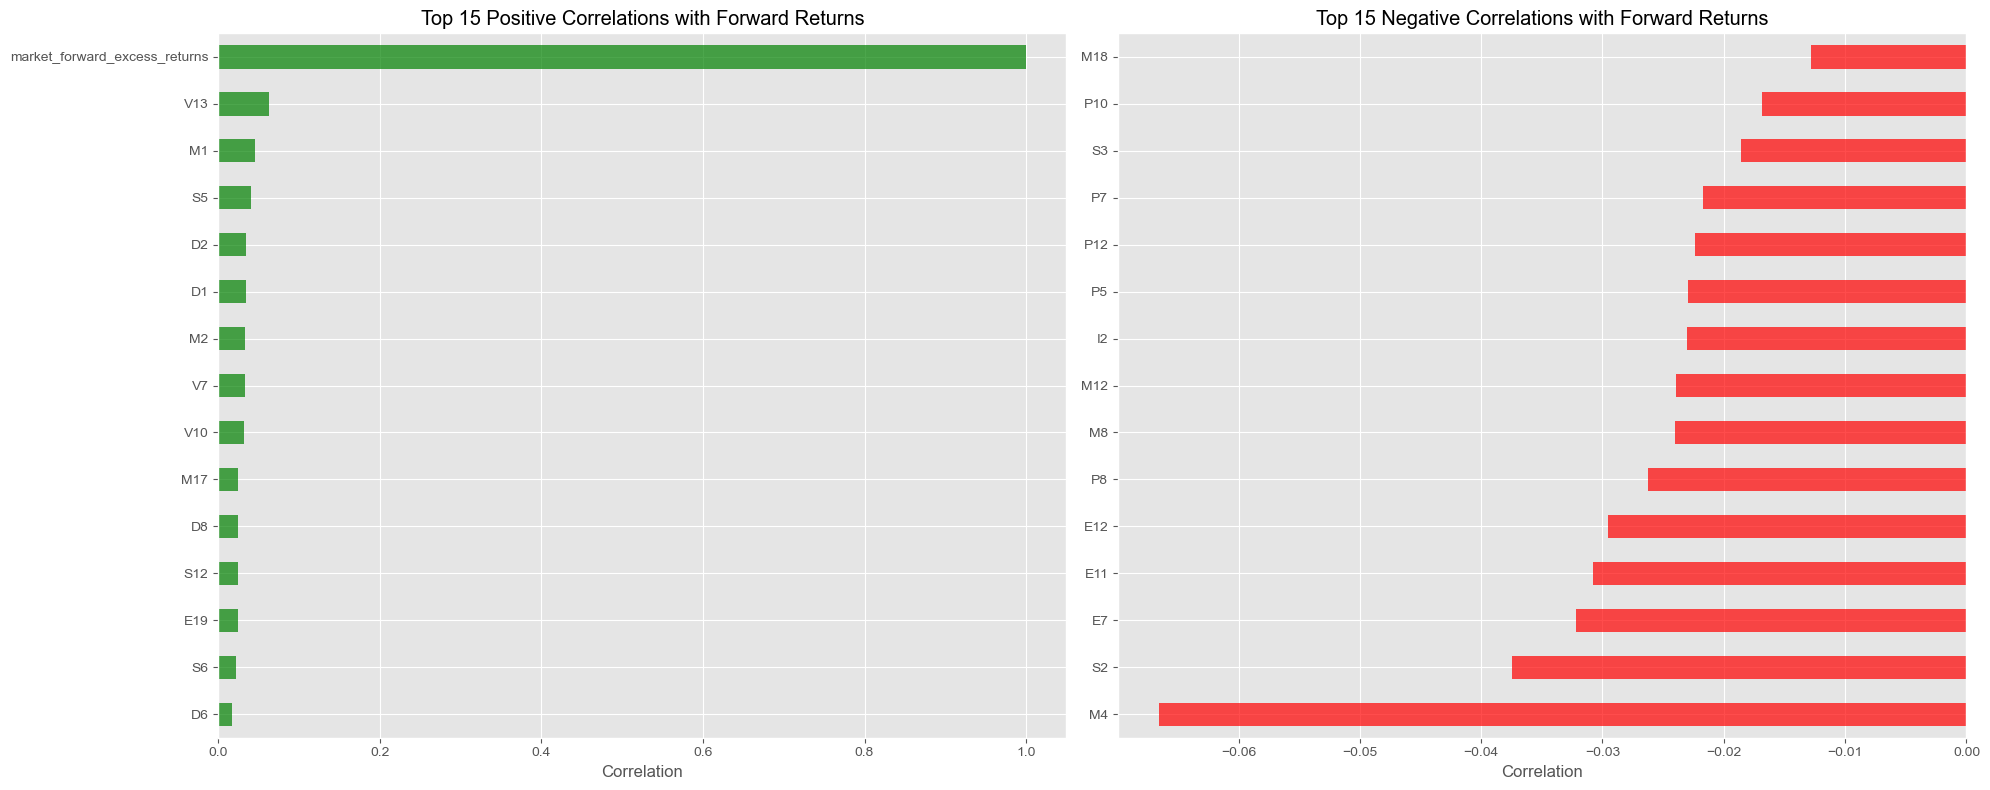


🔍 Market_Dynamics Internal Correlations:
  |r| > 0.8 の高相関ペアはありませんでした。


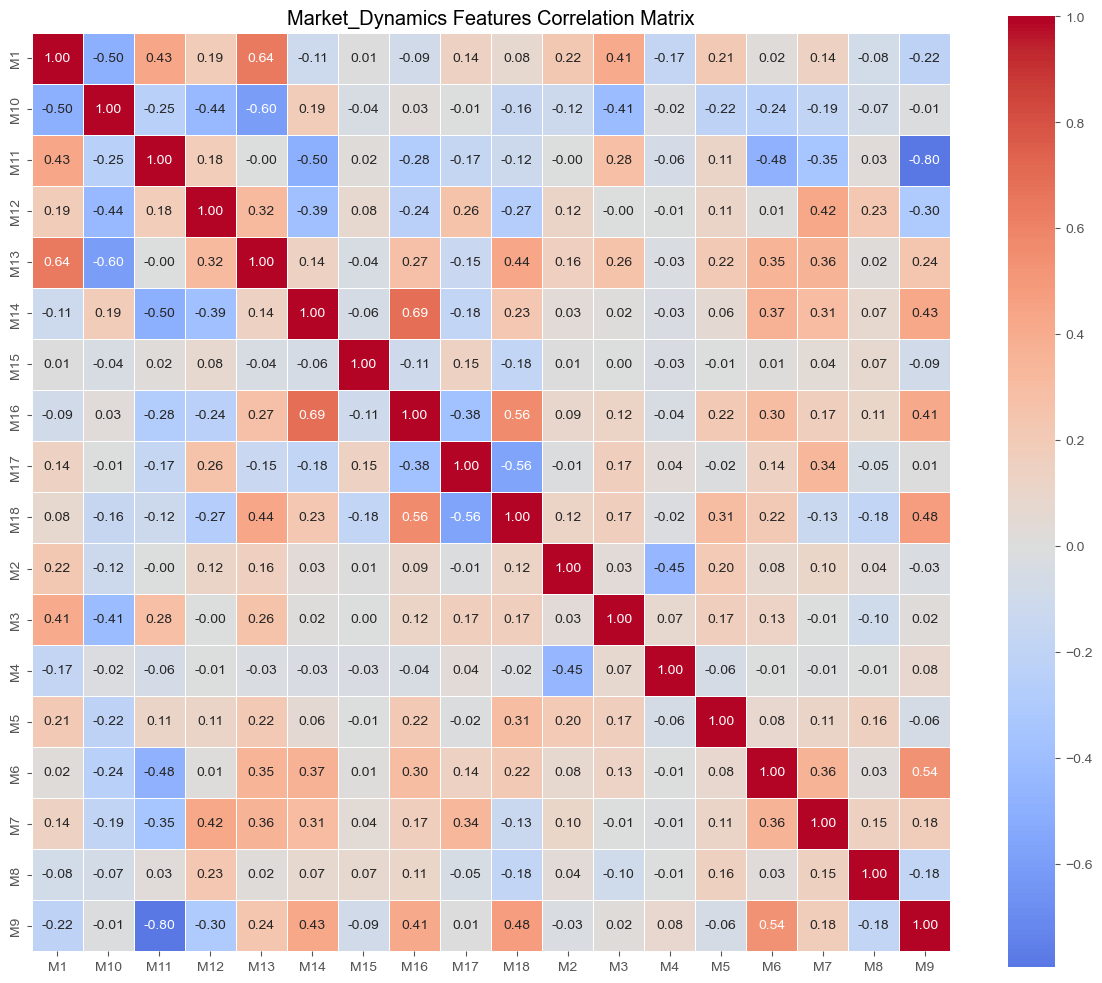


🔍 Macro_Economic Internal Correlations:
High correlations (|r| > 0.8): 5 pairs
  E15 - E9: 0.844
  E16 - E17: 0.929
  E16 - E18: 0.801
  E17 - E18: 0.886
  E2 - E3: 0.896


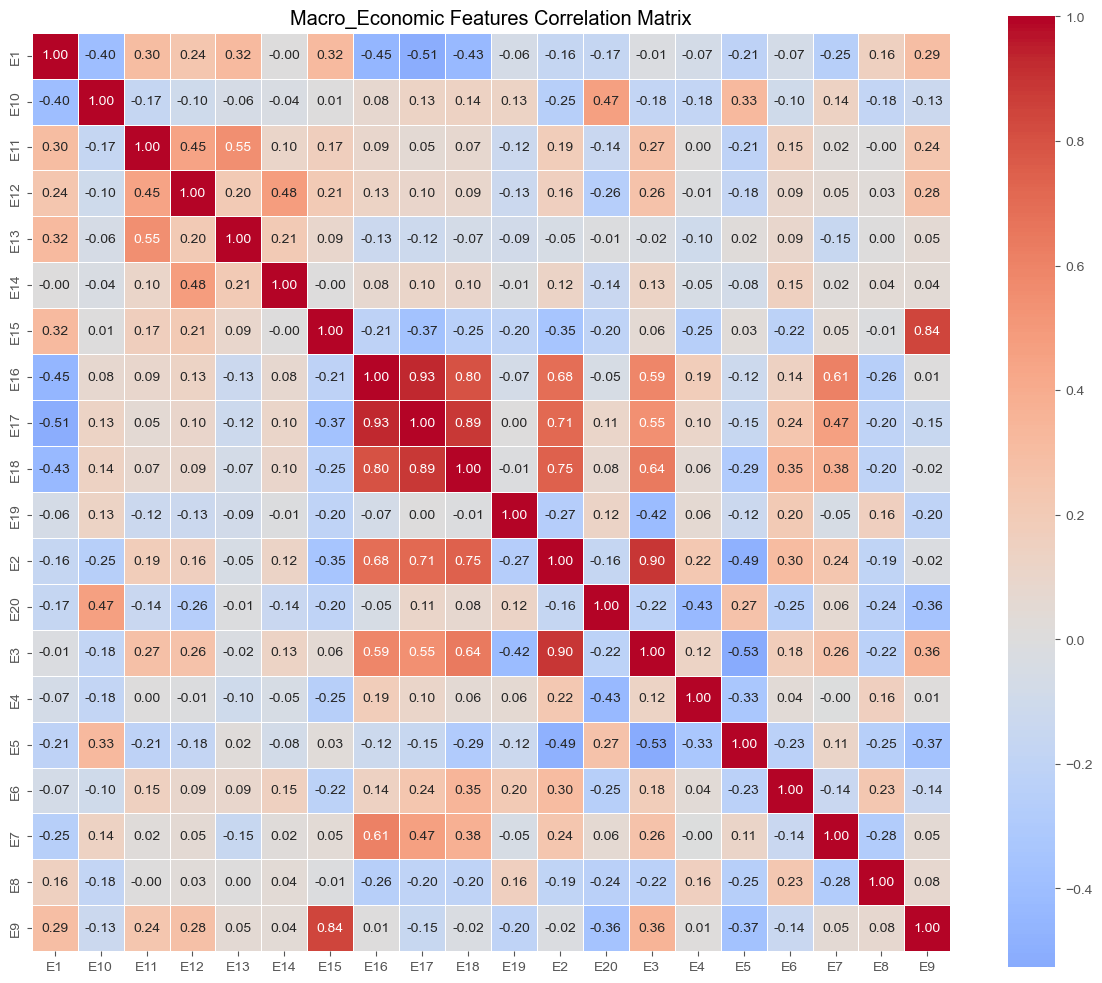


🔍 Interest_Rate Internal Correlations:
High correlations (|r| > 0.8): 2 pairs
  I4 - I8: 0.830
  I5 - I9: 1.000


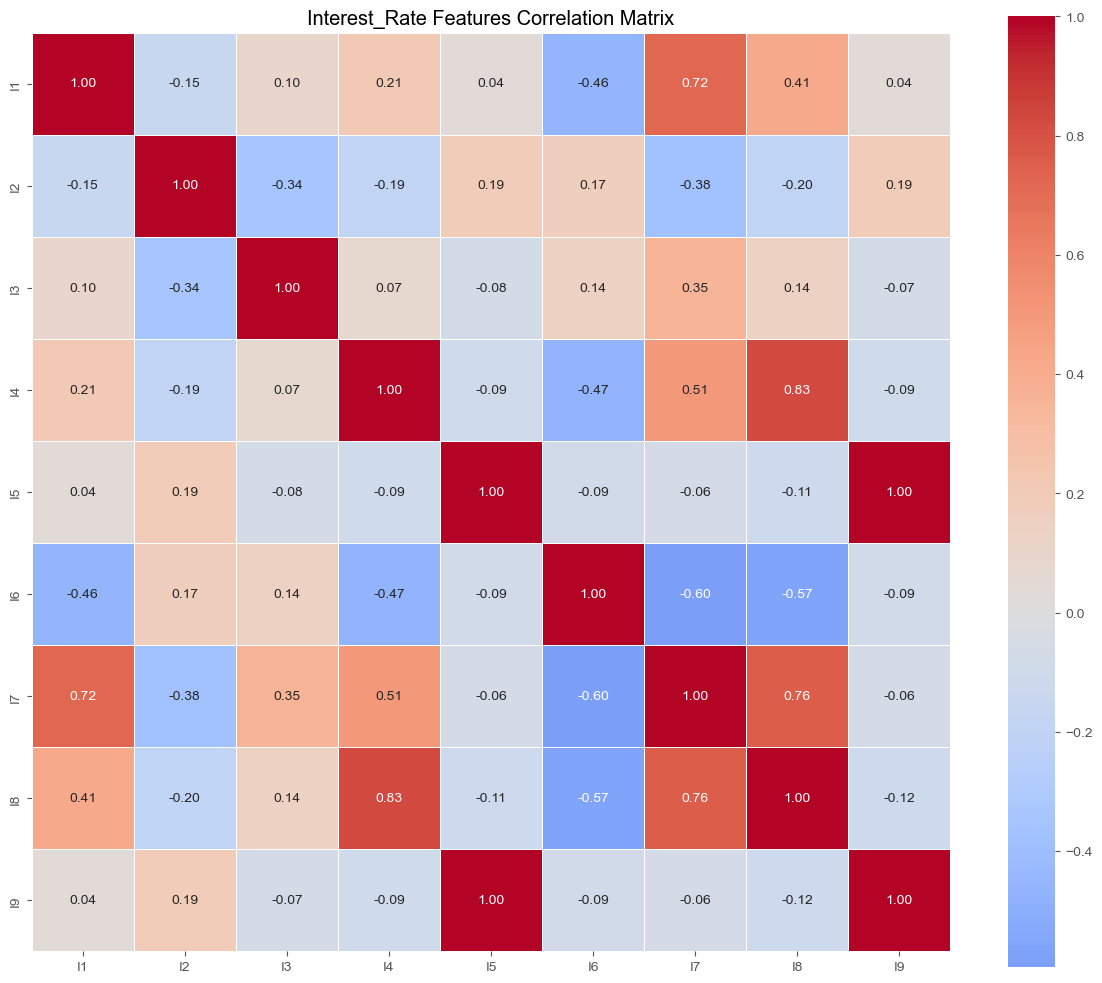


🔍 Price_Valuation Internal Correlations:
High correlations (|r| > 0.8): 2 pairs
  P10 - P11: 0.938
  P10 - P8: 0.807


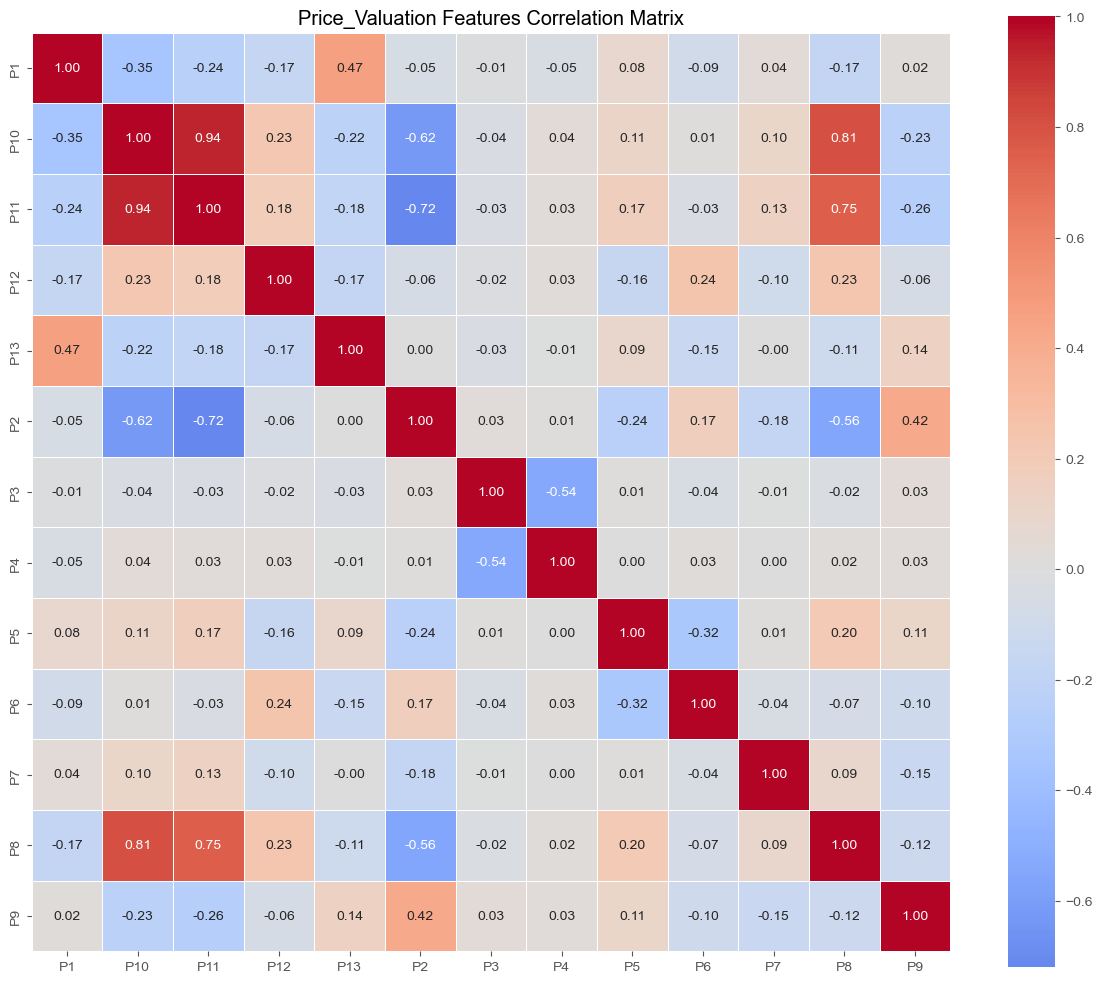


🔍 Volatility Internal Correlations:
High correlations (|r| > 0.8): 9 pairs
  V1 - V11: 0.877
  V1 - V2: 0.845
  V1 - V3: 0.802
  V1 - V4: 0.821
  V1 - V8: 0.873
  V10 - V7: 0.934
  V10 - V9: 0.985
  V2 - V4: 0.935
  V7 - V9: 0.977


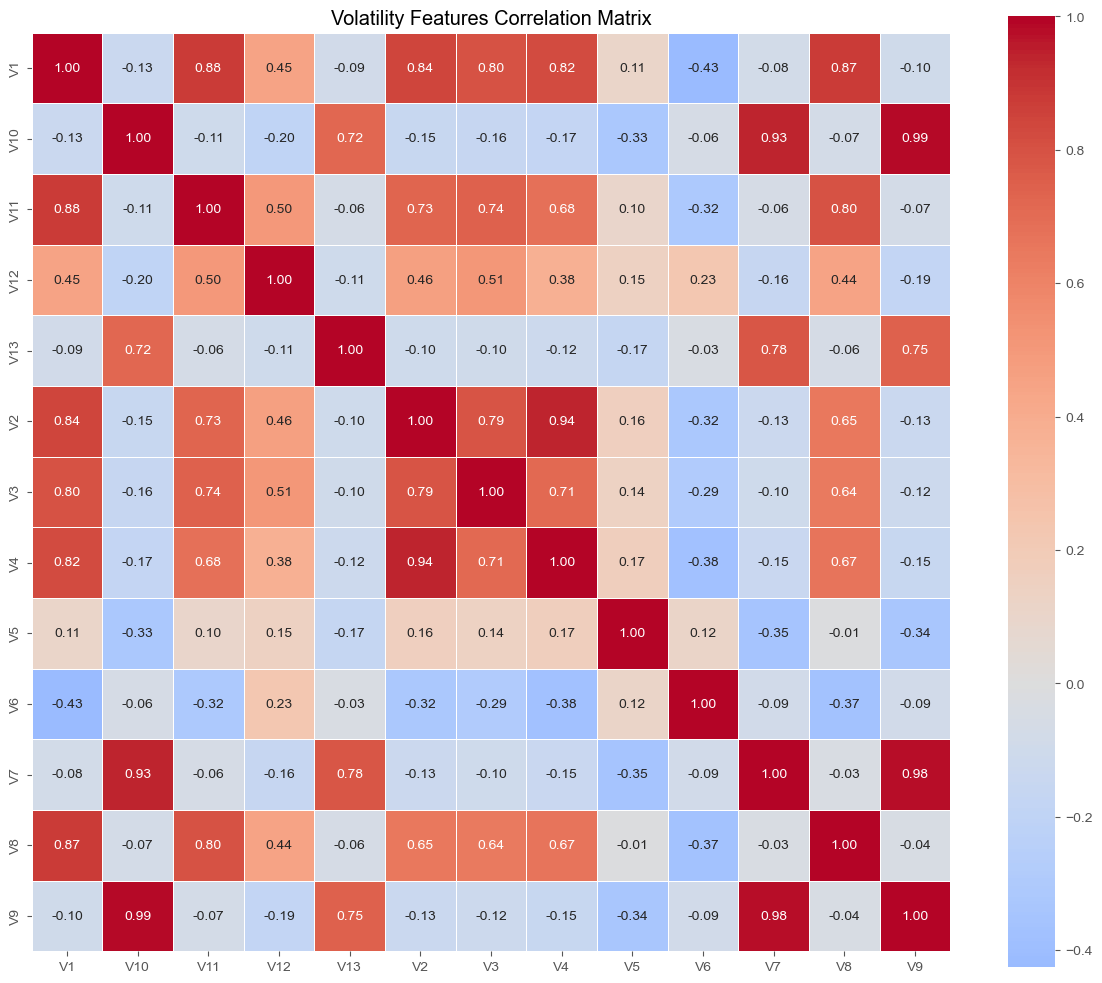


🔍 Sentiment Internal Correlations:
High correlations (|r| > 0.8): 3 pairs
  S10 - S11: 0.916
  S10 - S4: 0.819
  S11 - S4: 0.901


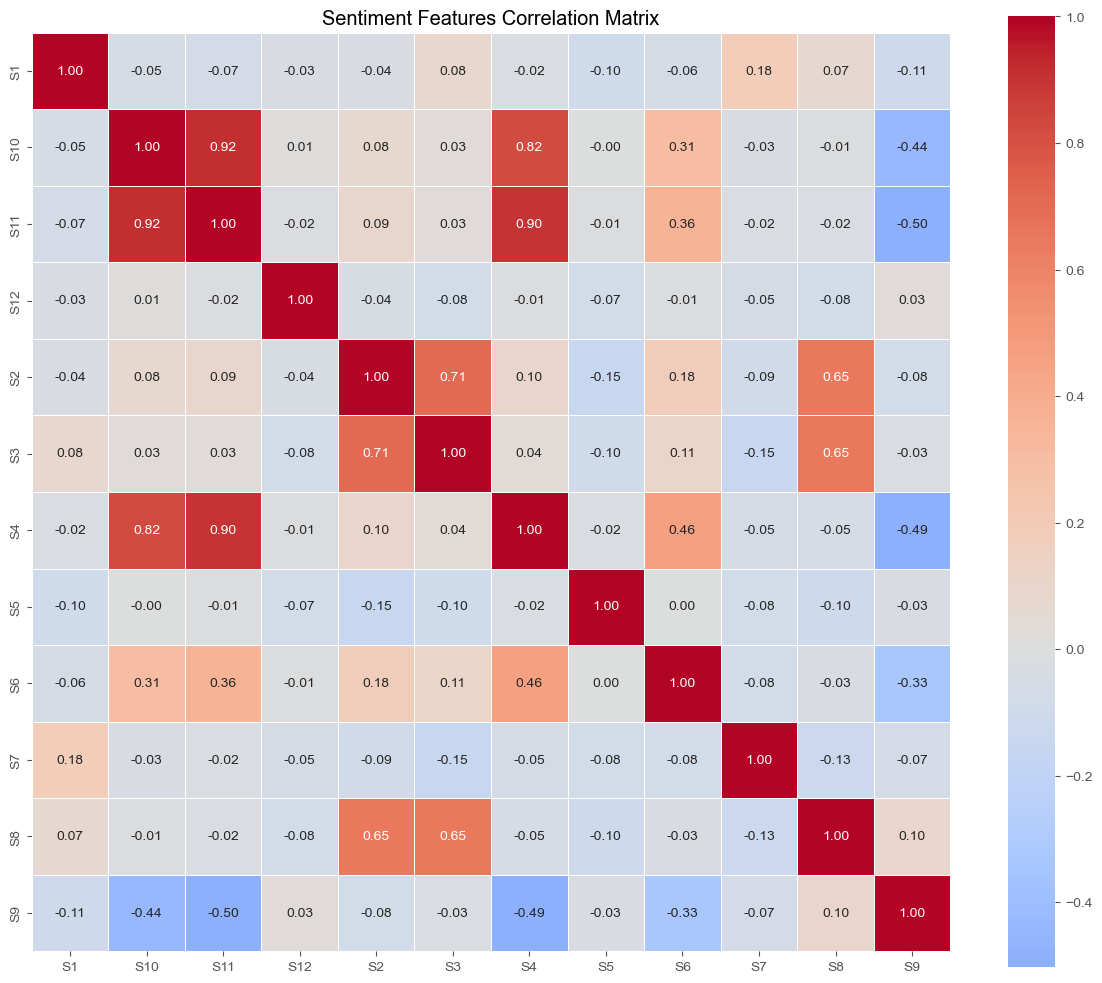


🔍 Dummy_Binary Internal Correlations:
High correlations (|r| > 0.8): 1 pairs
  D1 - D2: 1.000


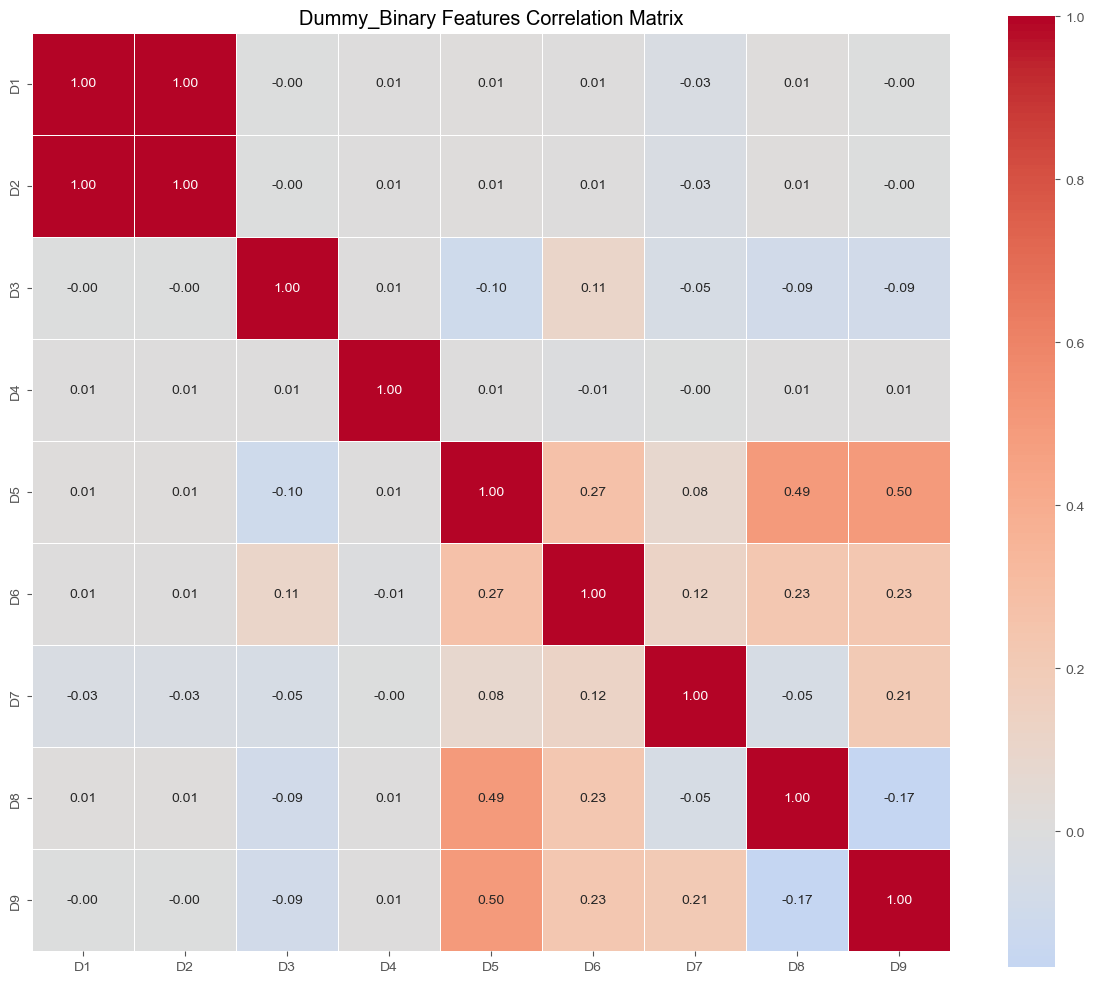

In [11]:

def analyze_correlations_pl(df: pl.DataFrame, feature_categories: dict):
    """Comprehensive correlation analysis for a Polars DataFrame"""
    
    print("="*50)
    
    # 数値型の定義（必要に応じて増やせます）
    numeric_types = {
        pl.Int8, pl.Int16, pl.Int32, pl.Int64,
        pl.UInt8, pl.UInt16, pl.UInt32, pl.UInt64,
        pl.Float32, pl.Float64
    }
    
    #---------------------------------------------------
    # 1. forward_returns との相関（全特徴）
    #---------------------------------------------------
    if "forward_returns" in df.columns:
        correlations = {}
        
        # forward_returns 自体が数値でないと相関が取れないので一応チェック
        if df.schema["forward_returns"] not in numeric_types:
            print("⚠ forward_returns が数値型ではありません。相関計算をスキップします。")
        else:
            for col in df.columns:
                if col == "forward_returns":
                    continue
                
                dtype = df.schema[col]
                if dtype not in numeric_types:
                    continue  # 数値でない列はスキップ
                
                # Polars で列同士の相関を計算
                corr_val = df.select(pl.corr(col, "forward_returns")).to_series().to_list()[0]
                if corr_val is not None:
                    correlations[col] = corr_val
            
            if len(correlations) > 0:
                target_corr = pd.Series(correlations).sort_values(ascending=False)
                
                print("🎯 TOP 20 FEATURES CORRELATED WITH FORWARD RETURNS:")
                print(target_corr.head(20))
                
                print("\n🎯 BOTTOM 20 FEATURES CORRELATED WITH FORWARD RETURNS:")
                print(target_corr.tail(20))
                
                # 上位・下位を可視化
                fig, axes = plt.subplots(1, 2, figsize=(20, 8))
                
                # Top positive correlations
                top_pos = target_corr.head(15)
                top_pos.plot(kind="barh", ax=axes[0], color="green", alpha=0.7)
                axes[0].set_title("Top 15 Positive Correlations with Forward Returns")
                axes[0].set_xlabel("Correlation")
                axes[0].invert_yaxis()
                
                # Top negative correlations
                top_neg = target_corr.tail(15)
                top_neg.plot(kind="barh", ax=axes[1], color="red", alpha=0.7)
                axes[1].set_title("Top 15 Negative Correlations with Forward Returns")
                axes[1].set_xlabel("Correlation")
                axes[1].invert_yaxis()
                
                plt.tight_layout()
                plt.show()
            else:
                print("※ forward_returns と相関を計算できる数値列がありませんでした。")
    
    #---------------------------------------------------
    # 2. カテゴリごとの相関（内部相関）
    #---------------------------------------------------
    for category, features in feature_categories.items():
        if category == "Special" or len(features) < 2:
            continue
        
        # ① DataFrame に存在する列だけ
        exists_features = [f for f in features if f in df.columns]
        if len(exists_features) < 2:
            continue
        
        # ② かつ「数値型の列だけ」に絞る ← ここが重要
        numeric_features = [
            f for f in exists_features
            if df.schema[f] in numeric_types
        ]
        if len(numeric_features) < 2:
            # そのカテゴリがほぼカテゴリ変数や ID だけの場合など
            print(f"\n🔍 {category} Internal Correlations:")
            print("  数値型の特徴量が2列未満のためスキップします。")
            continue
        
        print(f"\n🔍 {category} Internal Correlations:")
        
        # 対象列だけを選択し、欠損を含む行をドロップ
        category_df = df.select(numeric_features).drop_nulls()
        
        if category_df.height == 0:
            print("  有効な行がないためスキップします。")
            continue
        
        #---------------------------------------------------
        # NumPy で相関行列を計算（行: サンプル, 列: 特徴量）
        #---------------------------------------------------
        mat = category_df.to_numpy()  # shape = (n_samples, n_features)
        if mat.shape[1] < 2:
            print("  有効な数値特徴量が1列のみのためスキップします。")
            continue
        
        # ここで全て数値型になっているので np.corrcoef でエラーは出ない
        corr_np = np.corrcoef(mat, rowvar=False)  # (n_features, n_features)
        
        # pandas DataFrame にして扱いやすくする
        corr_matrix = pd.DataFrame(corr_np, index=numeric_features, columns=numeric_features)
        
        #---------------------------------------------------
        # |r| > 0.8 の高相関ペアを抽出
        #---------------------------------------------------
        high_corr_pairs = []
        cols = corr_matrix.columns
        for i in range(len(cols)):
            for j in range(i+1, len(cols)):
                corr_val = corr_matrix.iloc[i, j]
                if abs(corr_val) > 0.8:
                    high_corr_pairs.append((cols[i], cols[j], corr_val))
        
        if high_corr_pairs:
            print(f"High correlations (|r| > 0.8): {len(high_corr_pairs)} pairs")
            for pair in high_corr_pairs[:10]:  # 上位10件のみ表示
                print(f"  {pair[0]} - {pair[1]}: {pair[2]:.3f}")
        else:
            print("  |r| > 0.8 の高相関ペアはありませんでした。")
        
        #---------------------------------------------------
        # 特徴量が 20 以下ならヒートマップを描画
        #---------------------------------------------------
        if len(numeric_features) <= 20:
            plt.figure(figsize=(12, 10))
            sns.heatmap(
                corr_matrix,
                annot=True,
                cmap="coolwarm",
                center=0,
                square=True,
                linewidths=0.5,
                fmt=".2f"
            )
            plt.title(f"{category} Features Correlation Matrix")
            plt.tight_layout()
            plt.show()


analyze_correlations_pl(train_df, feature_categories)

1. ターゲットとの相関関係（forward_returns）
- 予想どおり、market_forward_excess_returnsは とほぼ完全に相関しています (0.9999+) forward_returns。
- それ以外では、弱い正の相関関係を示す特徴はごくわずかです（例：V13: 0.06、M1: 0.04、S5: 0.04）。
- マイナス側では、最も強い相関も小さいです（例：M4：-0.066、E7：-0.032）。


ただし、線形相関における 予測シグナルは極めて弱く、これは金融データに典型的に見られる現象です。これは、非線形モデルと相互作用効果の必要性を浮き彫りにしています。


2. カテゴリごとの内部相関
- マクロ経済（E*）
    - 強い冗長性：例：E16–E17（0.93）、E2–E3（0.90）。
    - 複数の機能が同様のマクロトレンドを捉えていることを示唆します。

- 金利（I*）
    - ほぼ完全な相関I5–I9（1.00） →同じレートの重複したエンコードである可能性が高い。
    - 満期ごとに一部重複あり（I4～I8：0.83）。

- 価格評価（P*）
    - 非常に高い重複：P10–P11（0.94）、P10–P8（0.81）。
    - 評価比率は互いの派生バージョンである可能性があることを示します。

- ボラティリティ（V*）
    - 重度のクラスタリング：例：V10–V9（0.98）、V7–V9（0.98）、V2–V4（0.94）。
    - ボラティリティ特性が非常に共線的であることを示唆しています。

- 感情（S*）
    - 注目すべき相関関係：S10–S11（0.92）、S11–S4（0.90）。
    - 投資家の感情を表す複数の指標が互いに密接に連動していることを示します。

- ダミー/バイナリ (D*)
    - D1–D2相関 = 1.00 → 完全に冗長。

これらの内容からカテゴリ内に 重度の多重共線性が存在することがわかります。過剰適合を避けるためには、特徴選択または次元削減（PCA、相互情報量、ドメインプルーニングセットなど）が重要になります。

3. ビジュアルインサイト
- 相関関係の棒グラフは、ほとんどの特徴がゼロ付近で推移していることを確認しており、単純な相関関係に基づく特徴のランキング付けはここでは役に立たないという考えを裏付けています。
- ヒートマップ(カテゴリ レベル) では、冗長クラスター (特にボラティリティとマクロ) が明確に強調表示されます。

## モデル構築と予測

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import lightgbm as lgb

train_df = pd.read_csv(BASE_DIR + "/train.csv")
test_df = pd.read_csv(BASE_DIR + "/test.csv")

target = "forward_returns"
features = [c for c in train_df.columns if c not in [target, "risk_free_rate"]]

X = train_df[features]
y = train_df[target]

# time-based split: last 20% as validation
split_idx = int(len(train_df) * 0.8)
X_train, X_val = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_val = y.iloc[:split_idx], y.iloc[split_idx:]

# --- モデル設計 ---
model = lgb.LGBMRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

model.fit(X_train, y_train,
          eval_set=[(X_val, y_val)],
          eval_metric="rmse",
          #early_stopping_rounds=50,
          #verbose=False
          #force_col_wise=true
         )

val_preds = model.predict(X_val)
mse = mean_squared_error(y_val, val_preds)  
rmse = np.sqrt(mse)                         
print(f"Validation RMSE: {rmse:.5f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002527 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 21894
[LightGBM] [Info] Number of data points in the train set: 7192, number of used features: 96
[LightGBM] [Info] Start training from score 0.000434
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [ ]:
# 予測
import os
from sklearn.linear_model import Ridge
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import kaggle_evaluation.default_inference_server 

target = "market_forward_excess_returns"
exclude_cols = ["date_id", target]
features = [c for c in train.columns if c not in exclude_cols]

X = train[features]
y = train[target]

# =======================
# Train Model
# =======================
model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])
model.fit(X, y)

# =======================
# Predict Function
# =======================
previous_allocation = 1.0  # start neutral

def predict(test: pl.DataFrame) -> float:
    global previous_allocation

    # Convert Polars -> Pandas
    row = test.to_pandas()

    # Make sure only training features are used
    row = row.reindex(columns=features, fill_value=0)

    # Predict
    pred = model.predict(row)[0]

    # Convert prediction into allocation
    allocation = 1.0 + 50 * pred  # scaling factor

    # Clip to [0, 2]
    allocation = np.clip(allocation, 0.0, 2.0)

    # Smooth with previous allocation
    allocation = 0.8 * allocation + 0.2 * previous_allocation

    previous_allocation = allocation
    return float(allocation)

inference_server = kaggle_evaluation.default_inference_server.DefaultInferenceServer(predict)

if os.getenv("KAGGLE_IS_COMPETITION_RERUN"):
    inference_server.serve()
else:
    inference_server.run_local_gateway(("/kaggle/input/hull-tactical-market-prediction/",))

ModuleNotFoundError: No module named 'kaggle_evaluation'

In [14]:
# Submit
import pandas as pd

def save_and_validate_submission(predictions, row_ids, filename="submission.parquet"):
    """
    Save predictions in Parquet format and validate structure before submission.
    """
    # Build dataframe
    submission = pd.DataFrame({
        "row_id": row_ids,
        "prediction": predictions
    })

    # Save to parquet
    submission.to_parquet(filename, index=False)

    # Reload to validate
    sub_check = pd.read_parquet(filename)

    # Validation checks
    print("✅ Submission saved as Parquet")
    print("Columns:", sub_check.columns.tolist())
    print("Number of rows:", len(sub_check))
    print("Missing values:", sub_check.isnull().sum().sum())
    print(sub_check.head())

    return filename

トレーニングデータにテストデータが含まれているため点数評価の仕方は気をつける必要がある。

## コメント

今回はporalsを使用してEDAを行ってみました。以前まではpandasを使用してデータ分析を行っていたのですがporalsのほうが早いだけでなく利便性も向上していると感じました。ただ、skit-learnとpolarの相性が悪いため、終盤はpandasを使用することになりました。IT分野はライブラリの移り変わりが激しいので新しいものを積極的に採用していきたいですが、ライブラリの互換性を気にしなければならないという点は難しいですね。


## 最後に
ここまで読んでいただきありがとうございました。私はデータ分析の学習のためにkaggleのコンペティションに参加しています。何かアドバイスや疑問点があればお気軽にコメントしてください。日本語でも英語でもどちらでも対応しています。...

参考

[Hull] Basic Approach and new feature (日本語/Eng): 
[https://www.kaggle.com/code/junjitakeshima/hull-basic-approach-and-new-feature-eng/notebook]

HTMP EDA which makes sense: 
[https://www.kaggle.com/code/ambrosm/htmp-eda-which-makes-sense]

Hull Tactical: Complete EDA Deep Dive: 
[https://www.kaggle.com/code/ahsuna123/hull-tactical-complete-eda-deep-dive]